#### USGS Streamflow Data Retrieval and Analysis at Regional Scale (Part 2)

This second part of the tutorial series extends the single‑station workflow introduced in **Part 1** to a **multi‑station, statewide analysis**. Rather than focusing on an individual watershed, this section applies the same data quality criteria and hydrologic diagnostics to **all qualifying USGS streamflow stations within Alabama**.

Building on the methods described previously, Part 2 demonstrates how to:

*   Identify **multiple streamflow stations** that meet consistent requirements for record length and data completeness over a common analysis period
*   Efficiently retrieve **daily discharge records in batches** using the `waterdata` API
*   Organize station data into both **long** and **wide** formats to support regional analysis
*   Group stations by **hydrologic connectivity** and visualize basin structure using NLDI network navigation
*   Apply **baseflow separation** and compute the **Baseflow Index (BFI)** consistently across many stations

The emphasis in Part 2 is on **scalability and comparative analysis**, enabling cross‑station evaluation of streamflow behavior. As in Part 1, the tutorial is fully standalone and executable. If running locally, ensure the required Python packages are installed:

```
pip install pandas numpy matplotlib shapely folium dataretrieval
```

#### Obtaining and Using an API Key

**Important:** To avoid request limits and ensure reliable access to USGS Water Data APIs, obtain an API key. Register for a key and set it as an environment variable before making requests. This step is essential for large downloads, continuous data, and automated workflows. Its also instantaneous and does not take time to obtain your own API

1. Register for a USGS API key [here](https://api.waterdata.usgs.gov/signup/)
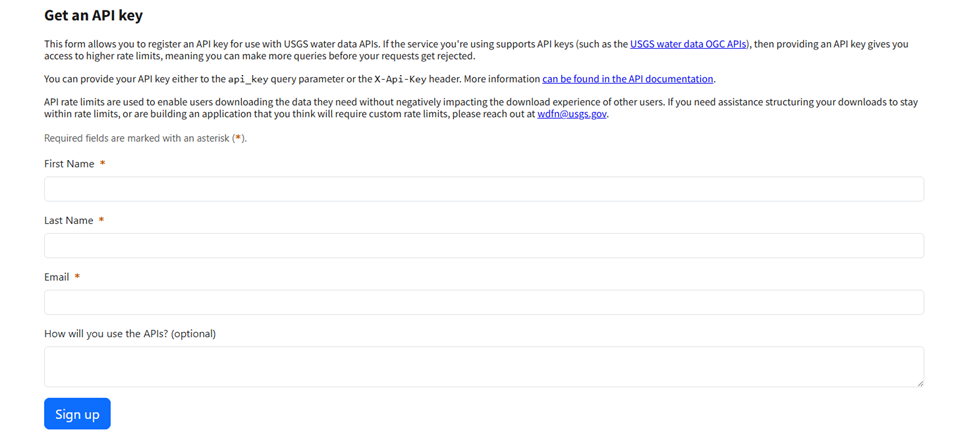

2. Set it as an environment variable

In [16]:
import os
os.environ["API_USGS_PAT"] = "**********" #"your_api_key_here"

#### Statewide Streamflow Station Screening

This section identifies **USGS streamflow stations across Alabama** that meet consistent data quality requirements for regional analysis. Using a fixed multi‑decadal window, daily discharge records are screened in batches to assess **record length** and **data completeness**.

Stations are retained if they:

*   Span **at least 15 years** within the analysis period
*   Have **less than 10 % missing daily values**

The output is a metadata table of qualifying stations, including location, drainage area, record span, and gap percentage. This table defines the station set used for all subsequent multi‑station analyses in Part 2.

In [2]:
from dataretrieval import waterdata
from shapely.geometry import Point
import pandas as pd

# Analysis window 
start_date, end_date = "2000-01-01", "2025-12-31"
expected_days = len(pd.date_range(start=start_date, end=end_date))

# Retrieve all USGS streamflow stations in Alabama. You can change to a State of your choice.
sites, _ = waterdata.get_monitoring_locations(
    state_name="Alabama",
    site_type_code="ST"
)

# Discovery loop over ALL stations
final_candidates = []
batch_size = 100
start_idx = 0

print(f"Scanning all Alabama stations with ≥15 years of data since {start_date}")

while start_idx < len(sites):
    batch = sites.iloc[start_idx : start_idx + batch_size]
    batch_ids = batch["monitoring_location_id"].tolist()

    try:
        df, _ = waterdata.get_daily(
            monitoring_location_id=batch_ids,
            parameter_code="00060",
            time=f"{start_date}/{end_date}"
        )

        if not df.empty:
            for sid, g in df.groupby("monitoring_location_id"):
                actual_count = g["value"].count()
                missing_pct = (1 - actual_count / expected_days) * 100
                years_span = (
                    (g["time"].max() - g["time"].min()).days / 365.25
                )

                # --- Selection criteria ---
                if years_span >= 15 and missing_pct < 10:
                    meta = batch.loc[
                        batch["monitoring_location_id"] == sid
                    ].iloc[0]

                    final_candidates.append({
                        "Site_ID": sid,
                        "Name": meta["monitoring_location_name"],
                        "Geometry": meta["geometry"],
                        "County": meta["county_name"],
                        "Drainage_Area": meta["drainage_area"],
                        "Years_Span": round(years_span, 1),
                        "Gap_%": round(missing_pct, 1),
                    })

    except Exception:
        pass

    start_idx += batch_size
    print(f"Scanned {start_idx} of {len(sites)} stations "
          f"Qualified so far: {len(final_candidates)}")

# Final table of qualifying stations
results_df = pd.DataFrame(final_candidates)
print("\nFinal Selection: Alabama Streamflow Stations (00060)")
results_df.head()

Scanning all Alabama stations with ≥15 years of data since 2000-01-01
Scanned 100 of 2666 stations → Qualified so far: 1
Scanned 200 of 2666 stations → Qualified so far: 4
Scanned 300 of 2666 stations → Qualified so far: 14
Scanned 400 of 2666 stations → Qualified so far: 20
Scanned 500 of 2666 stations → Qualified so far: 22
Scanned 600 of 2666 stations → Qualified so far: 25
Scanned 700 of 2666 stations → Qualified so far: 31
Scanned 800 of 2666 stations → Qualified so far: 34
Scanned 900 of 2666 stations → Qualified so far: 38
Scanned 1000 of 2666 stations → Qualified so far: 44
Scanned 1100 of 2666 stations → Qualified so far: 48
Scanned 1200 of 2666 stations → Qualified so far: 50
Scanned 1300 of 2666 stations → Qualified so far: 57
Scanned 1400 of 2666 stations → Qualified so far: 60
Scanned 1500 of 2666 stations → Qualified so far: 64
Scanned 1600 of 2666 stations → Qualified so far: 69
Scanned 1700 of 2666 stations → Qualified so far: 70
Scanned 1800 of 2666 stations → Qualifie

,Site_ID,Name,Geometry,County,Drainage_Area,Years_Span,Gap_%
0,USGS-02342500,"UCHEE CREEK NEAR FORT MITCHELL, AL.",POINT (-85.0149310773485 32.3168146732565),Russell County,322.0,26.0,0.0
1,USGS-02361000,"CHOCTAWHATCHEE RIVER NEAR NEWTON, AL.",POINT (-85.6104911505705 31.3429492287295),Dale County,686.0,26.0,0.0
2,USGS-02361500,CHOCTAWHATCHEE RIVER NEAR BELLWOOD AL,POINT (-85.7843789160369 31.1593422912818),Geneva County,1280.0,25.1,3.8
3,USGS-02363000,PEA RIVER NEAR ARITON AL,POINT (-85.7829975126913 31.5948871593948),Dale County,498.0,26.0,0.0
4,USGS-02369800,BLACKWATER RIVER NEAR BRADLEY AL,POINT (-86.7099566758569 31.0276798545901),Escambia County,87.7,26.0,0.0


#### Retrieving and Standardizing Daily Streamflow Data (Multiple Stations)

Using the screened station set from the previous step, this section retrieves **daily mean discharge (`00060`) for all qualifying stations** over the common analysis period. Station data are downloaded **in batches** to improve efficiency and then combined into a single dataset for regional analysis.

The workflow:

*   Retrieves daily discharge records for multiple stations in a single request
*   Combines all batches into one consolidated dataset
*   Renames and standardizes fields for consistency
*   Converts timestamps to a unified datetime index

The resulting table provides a clean, analysis‑ready collection of daily streamflow records across all selected stations and serves as the foundation for subsequent multi‑station hydrologic diagnostics.

In [4]:
from dataretrieval import waterdata
import pandas as pd

# Caveat, carefull not to hit limits especillay if you decide to change the parameters.
# can use smaller batches.
BATCH_SIZE = 25
station_ids = results_df["Site_ID"].tolist()
all_batches = []

print(f"Downloading daily discharge for {len(station_ids)} stations")

# Batched download
for i in range(0, len(station_ids), BATCH_SIZE):
    batch_ids = station_ids[i : i + BATCH_SIZE]

    print(f"  stations {i + 1} to {i + len(batch_ids)}")

    df, _ = waterdata.get_daily(
        monitoring_location_id=batch_ids,
        parameter_code="00060",
        time=f"{start_date}/{end_date}",
    )

    if not df.empty:
        all_batches.append(df)

# Combine all batches
df_all = pd.concat(all_batches, ignore_index=True)

# Clean & standardize
df_all = (
    df_all[["monitoring_location_id", "time", "value", "approval_status"]]
    .rename(
        columns={
            "monitoring_location_id": "site_id",
            "time": "date",
            "value": "discharge_cfs",
        }
    )
    .assign(date=lambda x: pd.to_datetime(x["date"]))
    .set_index("date")
    .sort_index()
)

print("\nDownload complete")
print(f"Total records: {len(df_all)}")
print(f"Number of stations: {df_all['site_id'].nunique()}")

df_all.head()

  stations 1 to 25
  stations 26 to 50
  stations 51 to 75
  stations 76 to 87

Download complete
Total records: 827330
Number of stations: 87


,site_id,discharge_cfs,approval_status
date,,,
2000-01-01,USGS-02342500,122.00,Approved
2000-01-01,USGS-02470072,0.46,Approved
2000-01-01,USGS-02469800,38.00,Approved
2000-01-01,USGS-02469761,3850.00,Approved
2000-01-01,USGS-02444160,1920.00,Approved


#### Organizing Multi‑Station Discharge Data in Wide Format

In this step, the consolidated daily discharge dataset is reshaped from a **long (record‑based)** format to a **wide (matrix‑style)** format. Each column represents a streamflow station, each row represents a date, and the values correspond to daily discharge.

This structure is useful for:

*   Cross‑station comparison and correlation analysis
*   Regional hydrologic statistics and diagnostics
*   Dimensionality‑reduction and machine‑learning workflows

Missing values are preserved as `NaN`

In [25]:
df_wide = (df_all.reset_index().pivot_table(index="date",
        columns="site_id", values="discharge_cfs", aggfunc="mean")
    .sort_index())

# Export to CSV for use in other tools
file_name = f"multi_station_daily_discharge.csv"
df_wide.to_csv(file_name)

print(df_wide.shape)
df_wide.iloc[:5, :5]   # first 5 days × first 5 stations

(9497, 87)


site_id,USGS-02342500,USGS-02361000,USGS-02361500,USGS-02363000,USGS-02369800
date,,,,,
2000-01-01,122.0,324.0,NaN,141.0,47.0
2000-01-02,125.0,323.0,NaN,139.0,46.0
2000-01-03,127.0,321.0,NaN,141.0,45.0
2000-01-04,135.0,335.0,NaN,145.0,47.0
2000-01-05,145.0,368.0,NaN,160.0,49.0


#### Baseflow Separation and Index Calculation (Multi‑Station)

Daily discharge records for all selected stations are processed individually using a **recursive digital filter** (`α = 0.925`) to partition streamflow into **quickflow** and **baseflow** components. The filter is applied consistently across stations to ensure comparability.

For each station, baseflow is computed as the slowly varying component of discharge, and a **Baseflow Index (BFI)** is calculated as the ratio of cumulative baseflow to total streamflow over the analysis period. The resulting BFI values provide a **station‑level diagnostic** of flow partitioning that supports regional comparison across sites.

The output is a summary table of BFI values for all stations, which forms the basis for subsequent regional synthesis and interpretation.

In [26]:
import numpy as np

alpha = 0.925
bfi_records = []

station_groups = {
    sid: g.sort_index()
    for sid, g in df_all.groupby("site_id")
}

for sid, df in station_groups.items():
    Q = df["discharge_cfs"].values
    q = np.zeros(len(Q))

    for t in range(1, len(Q)):
        q[t] = alpha * q[t-1] + ((1 + alpha) / 2) * (Q[t] - Q[t-1])
        q[t] = max(0, min(q[t], Q[t]))  # constrain quickflow

    baseflow = Q - q
    df["baseflow"] = baseflow
    df["quickflow"] = q

    # Baseflow Index
    bfi = baseflow.sum() / Q.sum()

    bfi_records.append({
        "site_id": sid,
        "BFI": bfi * 100,
        "n_days": len(Q)
    })

##### A Quick Visualization

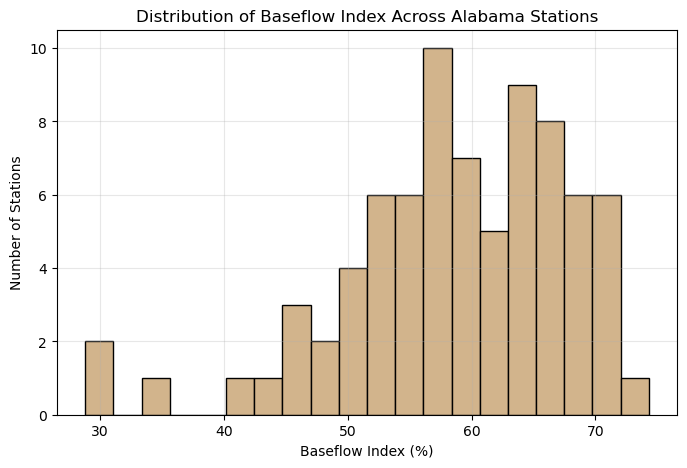

In [27]:
import matplotlib.pyplot as plt

bfi_df = pd.DataFrame(bfi_records).sort_values("BFI")

plt.figure(figsize=(8, 5))
plt.hist(bfi_df["BFI"], bins=20, color="tan", edgecolor="black")
plt.xlabel("Baseflow Index (%)")
plt.ylabel("Number of Stations")
plt.title("Distribution of Baseflow Index Across Alabama Stations")
plt.grid(alpha=0.3)
plt.show()